# HAR Model on the MHAR 5-min Feature Set

**Purpose:** The purpose of this notebook is to compute the out-of-sample forecast performance 
of the Heterogeneous Autoregressive (HAR) model of Corsi (2009) on the 
$\mathcal{M}_{\mathrm{HAR}}$ 5-min feature set for the EURO STOXX 50 index over the 
period 1999 - 2020, following the methodology of Christensen et al. (2023).

The model is defined as:

$$RV_{t+1} = \beta_0 + \beta_d RV_t + \beta_w \overline{RV}_t^{(w)} + 
\beta_m \overline{RV}_t^{(m)} + \varepsilon_{t+1}$$

where the predictors are the current day's realized variance measures:

- $RV_t$ (RVD) — daily realized variance
- $\overline{RV}_t^{(w)} = \frac{1}{5}\sum_{i=0}^{4} RV_{t-i}$ (RVW) — 
5-day rolling average of realized variance
- $\overline{RV}_t^{(m)} = \frac{1}{22}\sum_{i=0}^{21} RV_{t-i}$ (RVM) — 
22-day rolling average of realized variance

The model is estimated via Ordinary Least Squares (OLS) using a rolling window 
of fixed length equal to the combined training and validation set (4,389 
observations), rolling forward one day at a time across the test period of 
1,099 observations (2016-04-20 to 2020-08-05).

## 1. Loading Data
Loading in data from the MALL_5min.csv file

In [52]:
import pandas as pd
import numpy as np

# Load MALL dataset
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MALL_5min.csv"
MALL = pd.read_csv(file_path, index_col='Date', parse_dates=True)

print(f"Shape: {MALL.shape}")
print(f"Date range: {MALL.index[0].date()} to {MALL.index[-1].date()}")
print(f"NaN values: {MALL.isna().sum().sum()}")
MALL.head()

Shape: (5489, 31)
Date range: 1999-01-05 to 2020-08-06
NaN values: 0


,RVD,RVW,RVM,logRVD,logRVW,logRVM,RVD_pos,RVD_neg,RD_neg,RW_neg,...,BRENT,BRENT_ret,NIKKEI_ret,NIKKEI_sq,SP500_ret_lag,SP500_sq_lag,M1W,M1M,RV_target,logRV_target
Date,,,,,,,,,,,,,,,,,,,,,
1999-01-05,0.000106,0.000089,0.000141,-9.153100,-9.328531,-8.866447,0.000071,0.000035,0.000000,-0.000960,...,10.30,-0.060282,-0.013746,0.000189,-0.000920,8.458434e-07,0.087690,0.126206,0.000047,-9.966398
1999-01-06,0.000047,0.000090,0.000132,-9.966398,-9.316927,-8.935760,0.000038,0.000009,0.000000,-0.000960,...,10.67,0.035292,0.017657,0.000312,0.013491,1.819949e-04,0.100143,0.187219,0.000237,-8.347779
1999-01-07,0.000237,0.000123,0.000131,-8.347779,-9.004761,-8.938374,0.000110,0.000127,-0.012859,-0.003532,...,11.08,0.037706,0.005044,0.000025,0.021899,4.795626e-04,0.078881,0.184020,0.000168,-8.689606
1999-01-08,0.000168,0.000146,0.000114,-8.689606,-8.832472,-9.082830,0.000079,0.000089,-0.005883,-0.003748,...,11.70,0.054447,-0.010751,0.000116,-0.002053,4.216638e-06,0.078883,0.165510,0.000282,-8.175339
1999-01-11,0.000282,0.000168,0.000117,-8.175339,-8.692020,-9.056351,0.000067,0.000215,-0.025309,-0.008810,...,12.07,0.031134,-0.001744,0.000003,0.004212,1.774503e-05,0.001055,0.140613,0.000191,-8.565468


## 2. Data Split
### 2.1 Train / Validation / Test Split (70 / 10 / 20)

Following Christensen et al. (2023), we split the sample into a training set (70%), 
validation set (10%), and test set (20%). The test set is reserved exclusively for 
out-of-sample evaluation and no estimation or tuning is conducted on it.

In [15]:
# Train / Validation / Test split (70 / 10 / 20)
n = len(MALL)
n_train = int(np.floor(0.70 * n))
n_val   = int(np.floor(0.10 * n))
n_test  = n - n_train - n_val

train_idx = MALL.index[:n_train]
val_idx   = MALL.index[n_train:n_train + n_val]
test_idx  = MALL.index[n_train + n_val:]

print(f"Total observations: {n}")
print(f"\nTrain:      {train_idx[0].date()} to {train_idx[-1].date()} ({n_train} obs, {n_train/n*100:.1f}%)")
print(f"Validation: {val_idx[0].date()} to {val_idx[-1].date()} ({n_val} obs, {n_val/n*100:.1f}%)")
print(f"Test:       {test_idx[0].date()} to {test_idx[-1].date()} ({n_test} obs, {n_test/n*100:.1f}%)")

Total observations: 5489

Train:      1999-01-05 to 2014-02-26 (3842 obs, 70.0%)
Validation: 2014-02-27 to 2016-04-20 (548 obs, 10.0%)
Test:       2016-04-21 to 2020-08-06 (1099 obs, 20.0%)


## 3. HAR Model
### 3.1 Model Specification

The baseline HAR model is defined as:

$$RV_{t+1} = \beta_0 + \beta_d RV_t + \beta_w \overline{RV}_t^{(w)} + \beta_m \overline{RV}_t^{(m)} + \varepsilon_{t+1}$$

### 3.2 Feature Set Construction
Extracting the dependent and independent variables relevant for the HAR model

In [22]:
# Define target and feature set for MHAR
y      = MALL["RV_target"]
X_MHAR = MALL[["RVD", "RVW", "RVM"]]

print(f"Target variable: RV_target")
print(f"Predictors: {X_MHAR.columns.tolist()}")
print(f"\nFirst few rows:")
print(pd.concat([y, X_MHAR], axis=1).head())

Target variable: RV_target
Predictors: ['RVD', 'RVW', 'RVM']

First few rows:
            RV_target       RVD       RVW       RVM
Date                                               
1999-01-05   0.000047  0.000106  0.000089  0.000141
1999-01-06   0.000237  0.000047  0.000090  0.000132
1999-01-07   0.000168  0.000237  0.000123  0.000131
1999-01-08   0.000282  0.000168  0.000146  0.000114
1999-01-11   0.000191  0.000282  0.000168  0.000117


### 3.3 Rolling Window Estimation and Forecasting

Following Christensen et al. (2023), the HAR model is estimated via OLS using a rolling 
window of fixed length equal to the combined training and validation set (3,842 + 548 = 4,390 
observations). The window rolls forward one day at a time across the test set, producing 
one-step-ahead forecasts. Negative forecasts are replaced by the minimum in-sample realized 
variance following the insanity filter of Bollerslev, Patton, and Quaedvlieg (2016).

In [28]:
from sklearn.linear_model import LinearRegression

# Rolling window length = train + validation
window = n_train + n_val

forecasts_HAR = []
dates_test    = []

for i in range(n_test):
    # Extract rolling window
    X_window = X_MHAR.iloc[i : i + window].values
    y_window = y.iloc[i : i + window].values
    
    # OLS estimation
    model = LinearRegression()
    model.fit(X_window, y_window)
    
    # One-step-ahead forecast using time t predictors
    X_forecast = X_MHAR.iloc[i + window].values.reshape(1, -1)
    forecast   = model.predict(X_forecast)[0]
    
    # Insanity filter: replace negative forecasts with minimum in-sample RV
    min_rv   = y_window.min()
    forecast = max(forecast, min_rv)
    
    forecasts_HAR.append(forecast)
    dates_test.append(MALL.index[i + window])

print(f"Forecasts generated: {len(forecasts_HAR)}")
print(f"Forecast period: {dates_test[0].date()} to {dates_test[-1].date()}")

Forecasts generated: 1099
Forecast period: 2016-04-21 to 2020-08-06


### 3.4 Out-of-Sample Performance Evaluation

Following Christensen et al. (2023), out-of-sample forecast accuracy is evaluated using 
the Mean Squared Error (MSE):

$$MSE = \frac{1}{T}\sum_{t \in \text{test}} (RV_{t+1} - \hat{f}(Z_t))^2$$

where $\hat{f}(Z_t)$ is the one-step-ahead forecast and $T$ is the number of test observations.

In [32]:
# Collect results
results_HAR = pd.DataFrame({
    "RV_actual":   y.loc[dates_test].values,
    "RV_forecast": forecasts_HAR
}, index=dates_test)

# Compute out-of-sample MSE
mse_HAR = np.mean((results_HAR["RV_actual"] - results_HAR["RV_forecast"])**2)

print(f"Out-of-sample MSE (HAR): {mse_HAR:.6e}")
print(f"\nFirst few forecasts vs actuals:")
print(results_HAR.head(10).to_string())

Out-of-sample MSE (HAR): 5.663594e-08

First few forecasts vs actuals:
            RV_actual  RV_forecast
2016-04-21   0.000053     0.000101
2016-04-22   0.000081     0.000085
2016-04-25   0.000066     0.000090
2016-04-26   0.000059     0.000087
2016-04-27   0.000097     0.000084
2016-04-28   0.000147     0.000092
2016-04-29   0.000095     0.000113
2016-05-02   0.000105     0.000102
2016-05-03   0.000085     0.000107
2016-05-04   0.000093     0.000103


### 3.4.1 Save Forecasts 

In [44]:
import os

# Paths
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MHAR/Benchmark Models"
mse_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MHAR/Benchmark Models"

# Create BOTH directories
os.makedirs(forecast_path, exist_ok=True)
os.makedirs(mse_path, exist_ok=True)

# -------------------
# Save forecasts
# -------------------
results_HAR.to_csv(os.path.join(forecast_path, "forecasts_HAR.csv"))

# -------------------
# Create MSE summary
# -------------------
mse_summary_HAR = pd.DataFrame({
    "Model": ["HAR"],
    "MSE":   [mse_HAR],
    "RMSE":  [np.sqrt(mse_HAR)],
    "MAE":   [np.mean(np.abs(results_HAR["RV_actual"] - results_HAR["RV_forecast"]))],
    "Mean_Error": [np.mean(results_HAR["RV_actual"] - results_HAR["RV_forecast"])],
}).set_index("Model")

# -------------------
# Save MSE to MSE PATH (fix here)
# -------------------
mse_summary_HAR.to_csv(os.path.join(mse_path, "mse_summary_HAR.csv"))

# -------------------
# Print
# -------------------
print(f"Forecasts saved to: {forecast_path}")
print(f"MSE saved to: {mse_path}")
print(f"Files saved:")
print(f"  - forecasts_HAR.csv ({len(results_HAR)} rows)")
print(f"  - mse_summary_HAR.csv")
print(f"\nHAR MSE: {mse_HAR:.6e}")

Forecasts saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MHAR/Benchmark Models
MSE saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MHAR/Benchmark Models
Files saved:
  - forecasts_HAR.csv (1099 rows)
  - mse_summary_HAR.csv

HAR MSE: 5.663594e-08


## 4. Results
### 4.1 Forecast Visualization

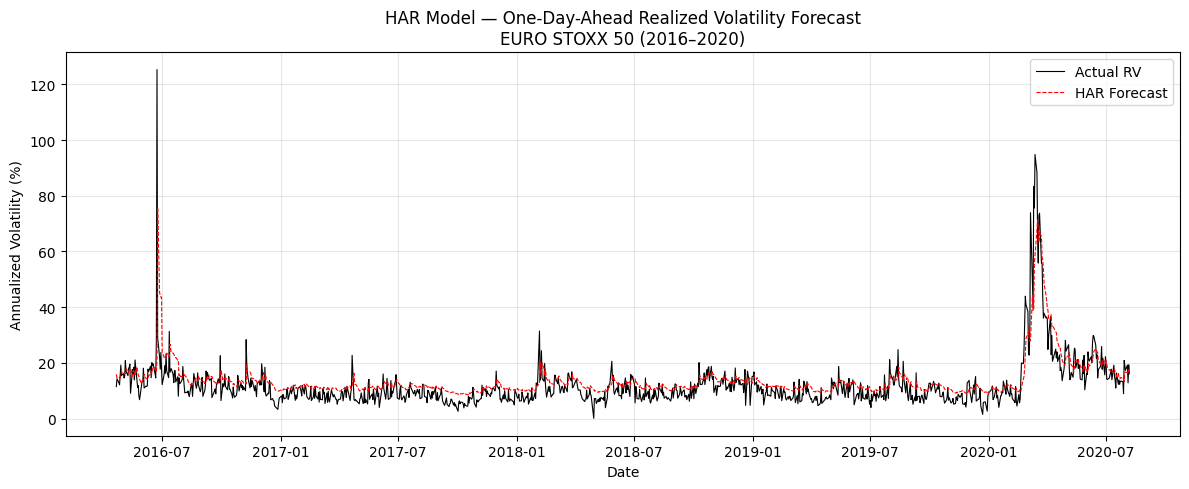


Summary of forecast errors:
Mean error:  -7.213307e-06
RMSE:        2.379831e-04
MAE:         5.258840e-05


In [38]:
import matplotlib.pyplot as plt

# Convert to annualized volatility for readability
results_plot = pd.DataFrame({
    "Actual":   np.sqrt(results_HAR["RV_actual"] * 252) * 100,
    "Forecast": np.sqrt(results_HAR["RV_forecast"] * 252) * 100
}, index=results_HAR.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_plot["Actual"],   label="Actual RV",       color="black",  linewidth=0.8)
ax.plot(results_plot["Forecast"], label="HAR Forecast",    color="red",    linewidth=0.8, linestyle="--")
ax.set_title("HAR Model — One-Day-Ahead Realized Volatility Forecast\nEURO STOXX 50 (2016–2020)", fontsize=12)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSummary of forecast errors:")
errors = results_HAR["RV_actual"] - results_HAR["RV_forecast"]
print(f"Mean error:  {errors.mean():.6e}")
print(f"RMSE:        {np.sqrt(mse_HAR):.6e}")
print(f"MAE:         {errors.abs().mean():.6e}")